In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import copy
import os
import numpy as np

In [3]:
def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state: np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X)*(1-test_size))
    return X[:split], X[split:], y[:split], y[split:]


In [4]:
def conv2d(X, W, b, stride=1, padding=0):
    X_padded = F.pad(X, (padding, padding, padding, padding))
    return F.conv2d(X_padded, W, bias=b, stride=stride)

def relu(X):
    return F.relu(X)

def maxpool2d(X, kernel_size=2, stride=2):
    return F.max_pool2d(X, kernel_size=kernel_size, stride=stride)


In [5]:
# Tiny CNN example
def forward_cnn(X, W1, b1, W2, b2, W_fc, b_fc):
    X = relu(conv2d(X, W1, b1))
    X = maxpool2d(X)
    X = relu(conv2d(X, W2, b2))
    X = maxpool2d(X)
    X = X.view(X.size(0), -1)
    logits = X @ W_fc + b_fc
    return logits


In [14]:
def init_cnn_params(device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Conv layer 1: 3x32x32 → 16 filters
    W1 = nn.Parameter(torch.randn(16, 3, 3, 3, device=device) * 0.01)
    b1 = nn.Parameter(torch.zeros(16, device=device))

    # Conv layer 2: 16 filters → 32 filters
    W2 = nn.Parameter(torch.randn(32, 16, 3, 3, device=device) * 0.01)
    b2 = nn.Parameter(torch.zeros(32, device=device))

    # ---- Compute flatten size dynamically ----
    with torch.no_grad():
        X_dummy = torch.zeros(1, 3, 32, 32, device=device)
        out = relu(conv2d(X_dummy, W1, b1))
        out = maxpool2d(out)
        out = relu(conv2d(out, W2, b2))
        out = maxpool2d(out)
        flatten_dim = out.view(1, -1).size(1)   # <- dynamic calc

    # Fully connected layer
    W_fc = nn.Parameter(torch.randn(flatten_dim, 10, device=device) * 0.01)
    b_fc = nn.Parameter(torch.zeros(10, device=device))

    return [W1, b1, W2, b2, W_fc, b_fc]


In [15]:
def train_cnn_functional_full(train_loader, val_loader,
                              epochs=50, lr=1e-3, weight_decay=1e-4,
                              scheduler_type="step", step_size=20, gamma=0.5,
                              early_stop_patience=10, device=None, checkpoint_path="best_func_cnn.pth"):
    # device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # init params (leaf tensors with requires_grad_)
    params = init_cnn_params()
    # move params to device
    for i, p in enumerate(params):
        params[i] = p.to(device)

    # optimizer expects list of leaf tensors
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    # scheduler
    if scheduler_type == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    elif scheduler_type == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    else:
        scheduler = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0.0
    best_state = None
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()
        # --- training ---
        running_loss = 0.0
        correct = 0
        total = 0
        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = forward_cnn(X, *params)  # params already on device
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # --- validation ---
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(device)
                y = y.to(device)
                logits = forward_cnn(X, *params)
                loss = F.cross_entropy(logits, y)
                val_running_loss += loss.item() * X.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # scheduler step
        if scheduler_type == "plateau" and scheduler is not None:
            scheduler.step(val_loss)
        elif scheduler is not None:
            scheduler.step()

        # checkpoint / early stopping
        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            epochs_no_improve = 0
            # save best params (copy them)
            best_state = [p.detach().cpu().clone() for p in params]
            torch.save(best_state, checkpoint_path)
            saved = True
        else:
            epochs_no_improve += 1
            saved = False

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{epochs}  Train Loss={train_loss:.4f}  Train Acc={train_acc*100:.2f}%  "
              f"Val Loss={val_loss:.4f}  Val Acc={val_acc*100:.2f}%  LR={optimizer.param_groups[0]['lr']:.6f}  "
              f"Saved={saved}  Time={epoch_time:.1f}s")

        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping triggered after {epoch+1} epochs (no improvement for {early_stop_patience} epochs).")
            break

    total_time = time.time() - start_time
    print(f"Training finished in {total_time/60:.2f} minutes. Best val acc: {best_val_acc*100:.2f}%")

    # load best params back into params list
    if best_state is not None:
        best_state = [p.to(device) for p in best_state]
        params = best_state

    # Plot curves
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")

    plt.show()

    # return params (trained) and best validation accuracy
    return params, best_val_acc


In [16]:
# Data (CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
val_loader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

Using device: cuda
Epoch 1/50  Train Loss=1.6940  Train Acc=39.42%  Val Loss=1.4765  Val Acc=47.81%  LR=0.001000  Saved=True  Time=18.3s
Epoch 2/50  Train Loss=1.4006  Train Acc=50.23%  Val Loss=1.3437  Val Acc=52.32%  LR=0.001000  Saved=True  Time=17.0s
Epoch 3/50  Train Loss=1.2846  Train Acc=54.79%  Val Loss=1.2450  Val Acc=56.10%  LR=0.001000  Saved=True  Time=16.5s
Epoch 4/50  Train Loss=1.2028  Train Acc=57.85%  Val Loss=1.1811  Val Acc=59.13%  LR=0.001000  Saved=True  Time=17.3s
Epoch 5/50  Train Loss=1.1375  Train Acc=60.24%  Val Loss=1.1277  Val Acc=61.18%  LR=0.001000  Saved=True  Time=16.3s
Epoch 6/50  Train Loss=1.0841  Train Acc=62.17%  Val Loss=1.0891  Val Acc=62.67%  LR=0.001000  Saved=True  Time=16.7s
Epoch 7/50  Train Loss=1.0386  Train Acc=63.97%  Val Loss=1.0992  Val Acc=61.85%  LR=0.001000  Saved=False  Time=17.0s
Epoch 8/50  Train Loss=0.9983  Train Acc=65.41%  Val Loss=1.0630  Val Acc=63.38%  LR=0.001000  Saved=True  Time=16.5s
Epoch 9/50  Train Loss=0.9716  Train

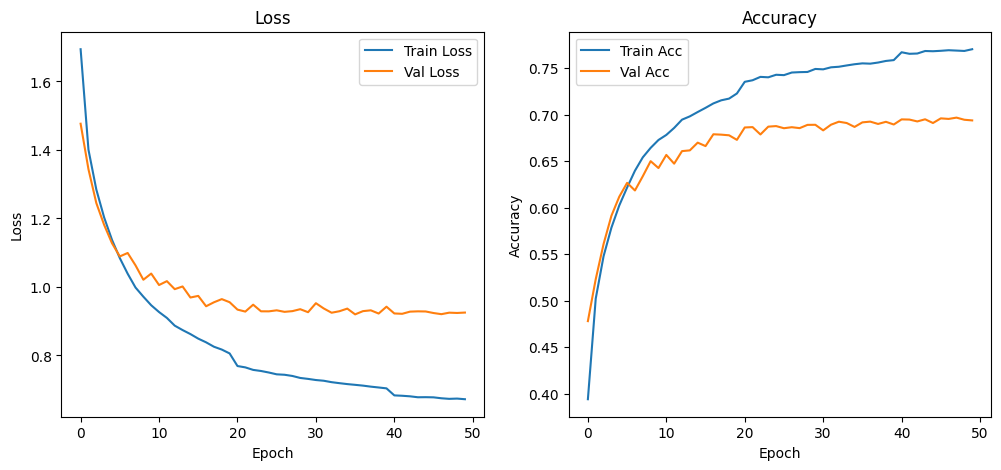

In [17]:
params = init_cnn_params()
params, best_val_acc = train_cnn_functional_full(
    train_loader, val_loader,
    epochs=50, lr=1e-3, weight_decay=1e-4,
    scheduler_type="step", step_size=20, gamma=0.5,
    early_stop_patience=10, device=None,
    checkpoint_path="best_func_cnn.pth"
)

In [18]:
results = {}

In [19]:
results["Functional CNN"] = best_val_acc

In [20]:
import json

results = {
    "CNN": best_val_acc  # from training
}

with open("results.json", "w") as f:
    json.dump(results, f)

In [21]:
with open("results.json", "r") as f:
    results = json.load(f)
print(results)

{'CNN': 0.6968}


In [ ]:
def rnn_step(x, h_prev, Wx, Wh, b):
    h = torch.tanh(x @ Wx + h_prev @ Wh + b)
    return h

def rnn_forward(X, Wx, Wh, b, h0):
    h = h0
    for t in range(X.size(1)):
        h = rnn_step(X[:,t,:], h, Wx, Wh, b)
    return h


In [ ]:
# ===============================
# Run RNN Training
# ===============================
train_losses = []

def train_rnn(X_seq, y_seq, Wx, Wh, b, W_out, b_out, lr=0.01, epochs=100):
    optimizer = torch.optim.SGD([Wx, Wh, b, W_out, b_out], lr=lr)
    for epoch in range(epochs):
        total_loss = 0
        for X, y in zip(X_seq, y_seq):
            h0 = torch.zeros(1, Wh.size(0))
            h = rnn_forward(X.unsqueeze(0), Wx, Wh, b, h0)
            logits = h @ W_out + b_out
            loss = F.cross_entropy(logits, y.unsqueeze(0))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(X_seq))
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss={train_losses[-1]:.4f}")

train_rnn(X_seq, y_seq, Wx, Wh, b, W_out, b_out, lr=0.01, epochs=50)

# Plot loss curve
plt.plot(train_losses, label="RNN Loss")
plt.title("RNN Training Loss")
plt.legend()
plt.show()


In [ ]:
def lstm_step(x, h_prev, c_prev, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    f = torch.sigmoid(x @ Wf + h_prev @ Wf + bf)
    i = torch.sigmoid(x @ Wi + h_prev @ Wi + bi)
    c_tilde = torch.tanh(x @ Wc + h_prev @ Wc + bc)
    c = f * c_prev + i * c_tilde
    o = torch.sigmoid(x @ Wo + h_prev @ Wo + bo)
    h = o * torch.tanh(c)
    return h, c


In [ ]:
# ===============================
# Run LSTM Training & Testing
# ===============================
model = SimpleLSTM(input_dim, hidden_dim, output_dim, num_layers)
train_losses, val_losses, train_accs, val_accs = train_lstm(
    model, train_loader, val_loader, epochs=5, lr=0.001
)

# Plot curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("LSTM Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("LSTM Accuracy")
plt.legend()

plt.show()

# Test accuracy
test_acc = test_lstm(model, test_loader)
print("Final Test Accuracy:", test_acc)


In [ ]:
def scaled_dot_product_attention(Q, K, V):
    """
    Q, K, V: (batch_size, seq_len, d_k)
    """
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(Q.size(-1), dtype=torch.float32))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V)

def multi_head_attention(X, WQ_list, WK_list, WV_list):
    """
    X: (batch_size, seq_len, embed_dim)
    WQ_list, WK_list, WV_list: list of weight matrices for each head
    """
    heads = []
    for WQ, WK, WV in zip(WQ_list, WK_list, WV_list):
        Q = X @ WQ
        K = X @ WK
        V = X @ WV
        head = scaled_dot_product_attention(Q, K, V)
        heads.append(head)
    return torch.cat(heads, dim=-1)


In [ ]:
def feed_forward(X, W1, b1, W2, b2):
    return F.relu(X @ W1 + b1) @ W2 + b2

def positional_encoding(seq_len, d_model):
    pos = torch.arange(seq_len).unsqueeze(1)
    i = torch.arange(d_model).unsqueeze(0)
    angle_rates = 1 / (10000 ** (2*(i//2)/d_model))
    angle_rads = pos * angle_rates
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = torch.cos(angle_rads[:, 1::2])
    return pe


In [ ]:
def transformer_encoder(X, WQ_list, WK_list, WV_list, W1, b1, W2, b2):
    # Multi-head attention
    attn_out = multi_head_attention(X, WQ_list, WK_list, WV_list)
    X = X + attn_out          # Residual connection
    X = F.layer_norm(X, X.size()[1:])  # Layer norm

    # Feedforward
    ff_out = feed_forward(X, W1, b1, W2, b2)
    X = X + ff_out            # Residual
    X = F.layer_norm(X, X.size()[1:])
    return X


In [ ]:
# Toy dataset: sentences labeled 0/1
data = [("I love AI", 1), ("AI is amazing",1), ("I hate bugs",0), ("This is terrible",0)]
all_text = " ".join([t for t,_ in data])
chars = sorted(list(set(all_text)))
char2idx = {c:i for i,c in enumerate(chars)}
vocab_size = len(chars)

def text_to_tensor(text):
    return torch.tensor([char2idx[c] for c in text], dtype=torch.long)

def one_hot_encode(seq, vocab_size):
    oh = torch.zeros(len(seq), vocab_size)
    oh[torch.arange(len(seq)), seq] = 1.0
    return oh


In [ ]:
seq_len = max(len(t[0]) for t in data)
d_model = 16
num_heads = 2

# Multi-head weights
WQ_list = [torch.randn(vocab_size,d_model//num_heads)*0.1 for _ in range(num_heads)]
WK_list = [torch.randn(vocab_size,d_model//num_heads)*0.1 for _ in range(num_heads)]
WV_list = [torch.randn(vocab_size,d_model//num_heads)*0.1 for _ in range(num_heads)]

# Feedforward weights
W1 = torch.randn(d_model, d_model*2)*0.1
b1 = torch.zeros(d_model*2)
W2 = torch.randn(d_model*2, d_model)*0.1
b2 = torch.zeros(d_model)

# Output linear layer
W_out = torch.randn(d_model,2)*0.1
b_out = torch.zeros(2)


In [ ]:
def forward_transformer(text, WQ_list, WK_list, WV_list, W1, b1, W2, b2, W_out, b_out):
    seq = text_to_tensor(text)
    x = one_hot_encode(seq, vocab_size).unsqueeze(0)  # (1, seq_len, vocab_size)
    pe = positional_encoding(x.size(1), d_model)
    if pe.size(1) != x.size(2):
        # Project positional encoding to vocab size if needed
        pe = torch.randn(x.size(1), x.size(2))
    x = x + pe
    out = transformer_encoder(x, WQ_list, WK_list, WV_list, W1, b1, W2, b2)
    out = out.mean(dim=1)  # Global average pooling over sequence
    logits = out @ W_out + b_out
    return logits


In [ ]:
def train_transformer(data, epochs=300, lr=0.01):
    global WQ_list, WK_list, WV_list, W1, b1, W2, b2, W_out, b_out
    for epoch in range(epochs):
        total_loss = 0
        for text, label in data:
            logits = forward_transformer(text, WQ_list, WK_list, WV_list, W1, b1, W2, b2, W_out, b_out)
            y = torch.tensor([label])
            loss = F.cross_entropy(logits, y)
            # Backprop manually
            for param in [W1,b1,W2,b2,W_out,b_out]+WQ_list+WK_list+WV_list:
                if param.grad is not None:
                    param.grad.zero_()
            loss.backward()
            with torch.no_grad():
                for param in [W1,b1,W2,b2,W_out,b_out]+WQ_list+WK_list+WV_list:
                    param -= lr * param.grad
            total_loss += loss.item()
        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(data):.4f}")

train_transformer(data, epochs=300)


In [ ]:
def predict_transformer(text):
    logits = forward_transformer(text, WQ_list, WK_list, WV_list, W1, b1, W2, b2, W_out, b_out)
    return torch.argmax(logits).item()

for text,_ in data:
    print(f"{text} -> {predict_transformer(text)}")


In [ ]:
# ===============================
# Run Transformer Training
# ===============================
train_losses = []

def train_transformer(block, X_seq, y_seq, lr=0.001, epochs=50):
    optimizer = torch.optim.Adam(block.parameters(), lr=lr)
    for epoch in range(epochs):
        total_loss = 0
        for X, y in zip(X_seq, y_seq):
            logits = block(X.unsqueeze(0))
            loss = F.cross_entropy(logits, y.unsqueeze(0))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(X_seq))
        if (epoch+1)%10 == 0:
            print(f"Epoch {epoch+1}, Loss={train_losses[-1]:.4f}")

train_transformer(block, X_seq, y_seq, lr=0.001, epochs=50)

# Plot loss curve
plt.plot(train_losses, label="Transformer Loss")
plt.title("Transformer Training Loss")
plt.legend()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Toy dataset: sequences of digits, label = 0 if sum even, 1 if odd
def generate_sequence_data(n_samples=500, seq_len=10, vocab_size=10):
    X = torch.randint(0, vocab_size, (n_samples, seq_len))
    y = (X.sum(dim=1) % 2).long()
    return X, y

X_seq, y_seq = generate_sequence_data(1000, seq_len=10, vocab_size=10)

# Train/test split
train_size = int(0.8 * len(X_seq))
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_test, y_test = X_seq[train_size:], y_seq[train_size:]


In [ ]:
def train_rnn_classifier(X_train, y_train, X_test, y_test, vocab_size=10, embed_dim=16, hidden_dim=32, epochs=10, lr=0.01):
    embed = nn.Embedding(vocab_size, embed_dim)
    Wx = torch.randn(embed_dim, hidden_dim, requires_grad=True) * 0.01
    Wh = torch.randn(hidden_dim, hidden_dim, requires_grad=True) * 0.01
    b = torch.zeros(hidden_dim, requires_grad=True)
    W_out = torch.randn(hidden_dim, 2, requires_grad=True) * 0.01
    b_out = torch.zeros(2, requires_grad=True)

    params = [Wx, Wh, b, W_out, b_out] + list(embed.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    for epoch in range(epochs):
        total_loss, correct = 0, 0
        for X, y in zip(X_train, y_train):
            h = torch.zeros(hidden_dim)
            for token in X:
                x_emb = embed(token.unsqueeze(0))
                h = torch.tanh(x_emb @ Wx + h @ Wh + b)
            logits = h @ W_out + b_out
            loss = F.cross_entropy(logits.unsqueeze(0), y.unsqueeze(0))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = torch.argmax(logits).item()
            correct += (pred == y.item())

        if (epoch+1)%2==0:
            acc = correct/len(X_train)
            print(f"Epoch {epoch+1} | Loss={total_loss/len(X_train):.4f} | Train Acc={acc:.4f}")

    # Evaluate
    correct = 0
    for X, y in zip(X_test, y_test):
        h = torch.zeros(hidden_dim)
        for token in X:
            x_emb = embed(token.unsqueeze(0))
            h = torch.tanh(x_emb @ Wx + h @ Wh + b)
        logits = h @ W_out + b_out
        pred = torch.argmax(logits).item()
        correct += (pred == y.item())
    test_acc = correct/len(X_test)
    return test_acc

rnn_acc = train_rnn_classifier(X_train, y_train, X_test, y_test)
print("RNN Test Accuracy:", rnn_acc)


In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, num_heads=2, hidden_dim=64, num_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = self.embed(x)
        attn_out, _ = self.attn(x, x, x)
        x = attn_out.mean(dim=1)  # global average pooling
        return self.ff(x)

def train_transformer_classifier(X_train, y_train, X_test, y_test, vocab_size=10, epochs=10, lr=0.001):
    model = TransformerClassifier(vocab_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss, correct = 0, 0
        for X, y in zip(X_train, y_train):
            logits = model(X.unsqueeze(0))
            loss = F.cross_entropy(logits, y.unsqueeze(0))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = torch.argmax(logits).item()
            correct += (pred == y.item())

        if (epoch+1)%2==0:
            acc = correct/len(X_train)
            print(f"Epoch {epoch+1} | Loss={total_loss/len(X_train):.4f} | Train Acc={acc:.4f}")

    # Evaluate
    correct = 0
    for X, y in zip(X_test, y_test):
        logits = model(X.unsqueeze(0))
        pred = torch.argmax(logits).item()
        correct += (pred == y.item())
    test_acc = correct/len(X_test)
    return test_acc

transformer_acc = train_transformer_classifier(X_train, y_train, X_test, y_test)
print("Transformer Test Accuracy:", transformer_acc)
